# BMVC 2026 Paper Data Collection

This notebook collects all data needed for the paper:
1. **Sample images** - One image per class for all 4 use cases (for figures)
2. **Training time** - 2-epoch timing run for all 8 models, extrapolated to full training
3. **Accuracy confirmation** - Verify reported metrics match saved results

Run on: GCP `slm-workbench-l4` (1x L4 24GB)

In [33]:
import os, sys, json, time, random, glob
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Add task paths for config imports
sys.path.insert(0, 'task4-fine-tuning/granulometry')
sys.path.insert(0, 'task4-fine-tuning/steel-surface')
sys.path.insert(0, 'task4-fine-tuning/uhcs-microstructure')
sys.path.insert(0, 'task4-fine-tuning/riawelc-weld')

random.seed(42)
print('Setup complete')

Setup complete


---
## Part 1: Sample Images Per Class

Save one representative image per class for each use case.
These will be used in the paper figures.

In [34]:
OUTPUT_DIR = 'papers/bmvc2026/paper_figures/sample_images'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Uniform thumbnail size for all saved images
THUMB_SIZE = (300, 300)

### 1.1 Granulometry (9 classes)

In [35]:
GRAN_TEST_DIR = 'datasets/granulometry/test'
GRAN_MANIFEST = 'datasets/granulometry/test_manifest.json'

with open(GRAN_MANIFEST) as f:
    gran_manifest = json.load(f)

# Ground truth mapping from filename
GRAN_GT = {
    'A8': (8, 'coarse'), 'A16': (16, 'coarse'), 'A32': (32, 'coarse'),
    'B8': (8, 'medium'), 'B16': (16, 'medium'), 'B32': (32, 'medium'),
    'C8': (8, 'fine'),   'C16': (16, 'fine'),   'C32': (32, 'fine'),
}

# Pick one image per class
gran_samples = {}
for entry in gran_manifest:
    cls = entry['class']
    if cls not in gran_samples:
        gran_samples[cls] = entry['image']

# Save samples
os.makedirs(f'{OUTPUT_DIR}/granulometry', exist_ok=True)
for cls, fname in sorted(gran_samples.items()):
    src = os.path.join(GRAN_TEST_DIR, fname)
    if os.path.exists(src):
        img = Image.open(src).convert('RGB')
        img = img.resize(THUMB_SIZE, Image.LANCZOS)
        img.save(f'{OUTPUT_DIR}/granulometry/{cls}.jpg')
        size, grading = GRAN_GT[cls]
        print(f'  {cls}: {size}mm, {grading} -> {fname}')
    else:
        print(f'  {cls}: FILE NOT FOUND {src}')

print(f'\nSaved {len(gran_samples)} granulometry samples')

  A16: 16mm, coarse -> S1_A16_IMG_7670.JPG
  A32: 32mm, coarse -> S1_A32_IMG_5952.JPG
  A8: 8mm, coarse -> S1_A8_IMG_7736.JPG
  B16: 16mm, medium -> S1_B16_IMG_7797.JPG
  B32: 32mm, medium -> S1_B32_IMG_5813.JPG
  B8: 8mm, medium -> S1_B8_IMG_5790.JPG
  C16: 16mm, fine -> S1_C16_IMG_7674.JPG
  C32: 32mm, fine -> S1_C32_IMG_5901.JPG
  C8: 8mm, fine -> S1_C8_IMG_5780.JPG

Saved 9 granulometry samples


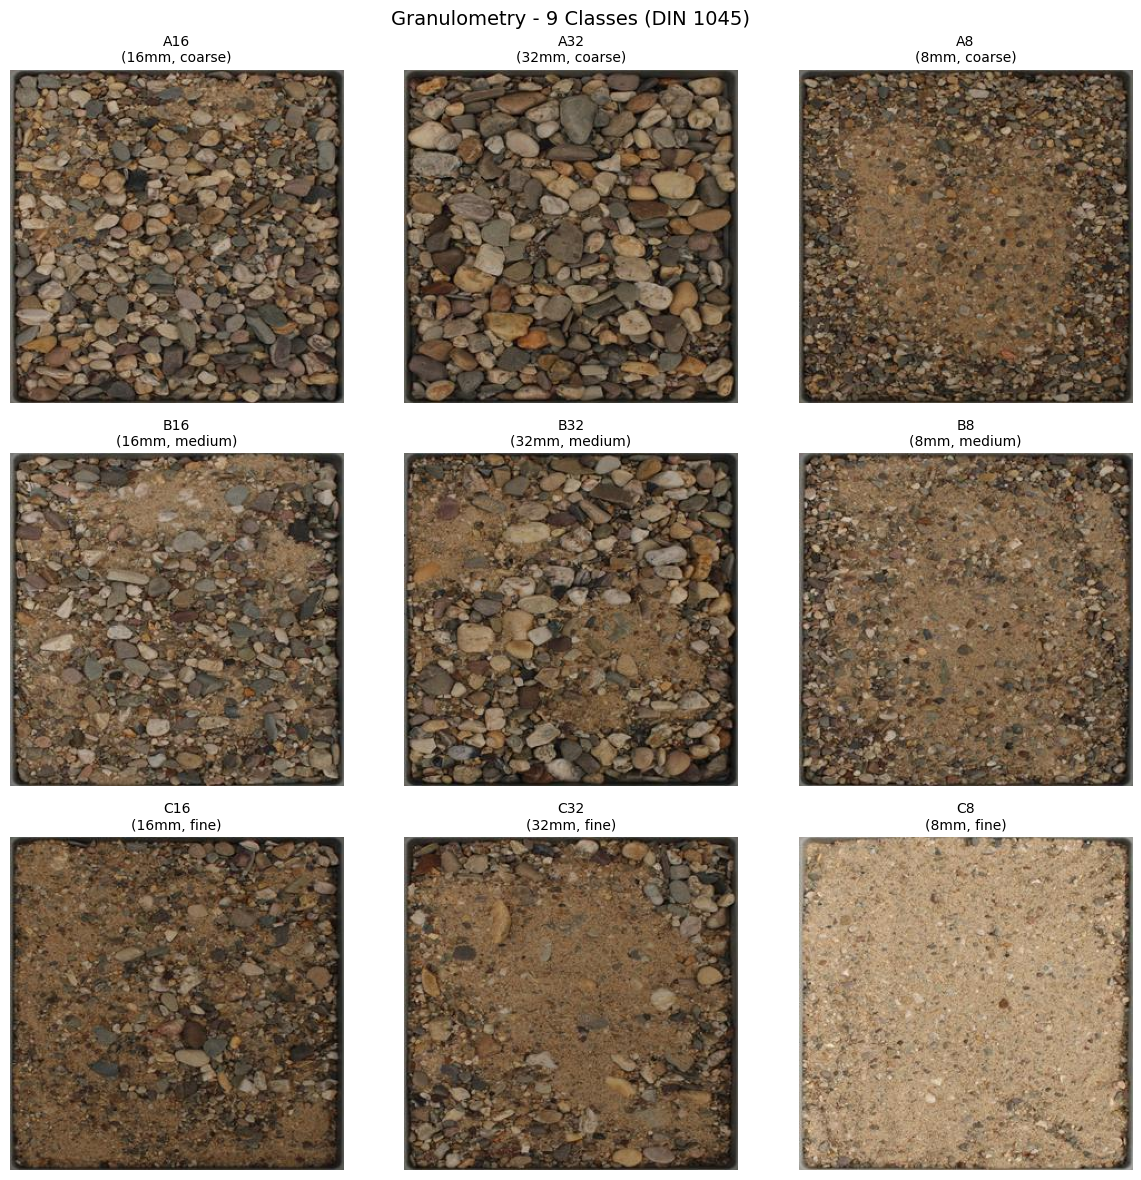

In [36]:
# Display granulometry samples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Granulometry - 9 Classes (DIN 1045)', fontsize=14)
for idx, cls in enumerate(sorted(gran_samples.keys())):
    ax = axes[idx // 3, idx % 3]
    img_path = f'{OUTPUT_DIR}/granulometry/{cls}.jpg'
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
    size, grading = GRAN_GT[cls]
    ax.set_title(f'{cls}\n({size}mm, {grading})', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/granulometry_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Steel Surface Defects (6 classes)

In [37]:
STEEL_TEST_DIR = 'datasets/neu-cls/NEU-DET/validation/images'
STEEL_CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

os.makedirs(f'{OUTPUT_DIR}/steel_surface', exist_ok=True)
for cls in STEEL_CLASSES:
    # Images are in subdirectories per class
    cls_dir = os.path.join(STEEL_TEST_DIR, cls)
    if os.path.isdir(cls_dir):
        files = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg'))])
        if files:
            src = os.path.join(cls_dir, files[0])
            img = Image.open(src).convert('RGB')
            img = img.resize(THUMB_SIZE, Image.LANCZOS)
            img.save(f'{OUTPUT_DIR}/steel_surface/{cls}.png')
            print(f'  {cls}: {files[0]} (from {len(files)} total)')
        else:
            print(f'  {cls}: directory empty')
    else:
        # Fallback: try flat file naming
        pattern = os.path.join(STEEL_TEST_DIR, f'{cls}_*')
        matches = sorted(glob.glob(pattern))
        if matches:
            img = Image.open(matches[0]).convert('RGB')
            img = img.resize(THUMB_SIZE, Image.LANCZOS)
            img.save(f'{OUTPUT_DIR}/steel_surface/{cls}.png')
            print(f'  {cls}: {os.path.basename(matches[0])}')
        else:
            print(f'  {cls}: NO IMAGES FOUND')

print(f'\nSaved steel surface samples')

  crazing: crazing_241.jpg (from 60 total)
  inclusion: inclusion_241.jpg (from 60 total)
  patches: patches_241.jpg (from 60 total)
  pitted_surface: pitted_surface_241.jpg (from 60 total)
  rolled-in_scale: rolled-in_scale_241.jpg (from 60 total)
  scratches: scratches_241.jpg (from 60 total)

Saved steel surface samples


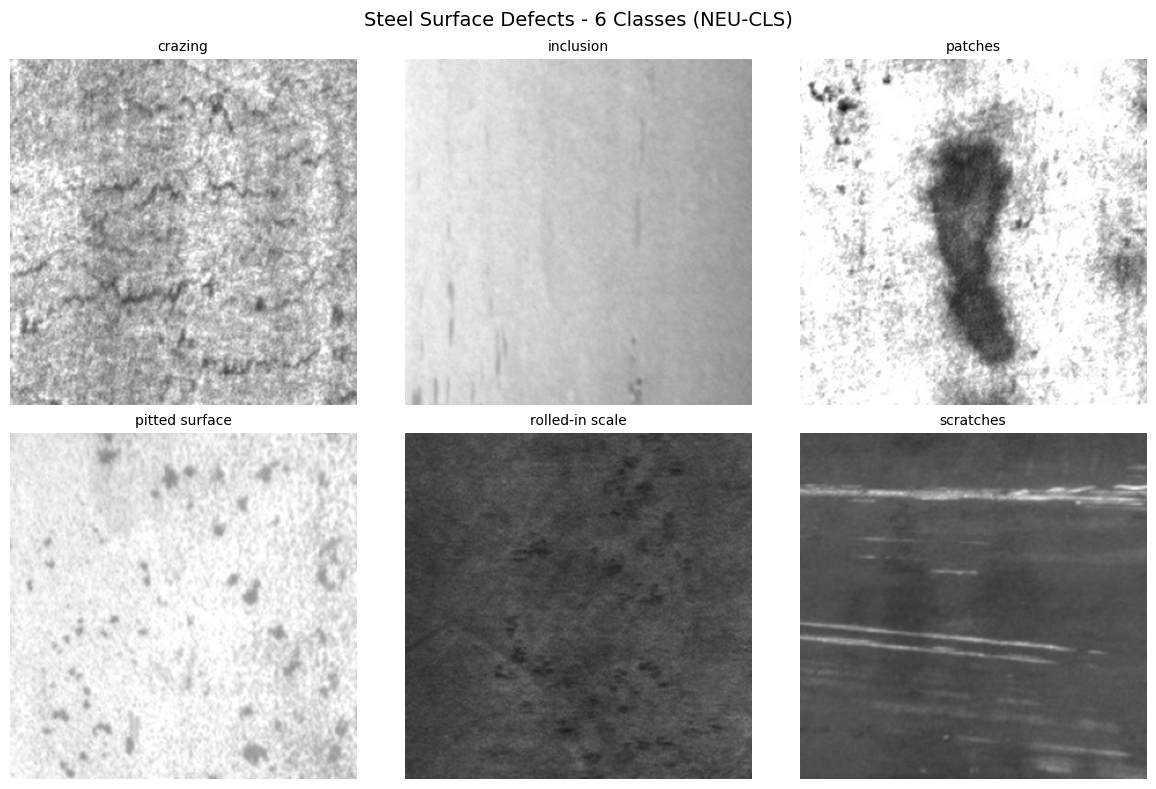

In [38]:
# Display steel surface samples
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Steel Surface Defects - 6 Classes (NEU-CLS)', fontsize=14)
for idx, cls in enumerate(STEEL_CLASSES):
    ax = axes[idx // 3, idx % 3]
    img_path = f'{OUTPUT_DIR}/steel_surface/{cls}.png'
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')
    ax.set_title(cls.replace('_', ' '), fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/steel_surface_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 UHCS Microstructure (5 classes)

In [39]:
UHCS_IMAGES_DIR = 'datasets/uh-carbon-steel/For Training/Cropped'
UHCS_METADATA = 'datasets/uh-carbon-steel/new_metadata.xlsx'
UHCS_CLASSES = ['spheroidite', 'network', 'spheroidite+widmanstatten', 'pearlite+spheroidite', 'pearlite']

# UHCS needs metadata to map filenames to classes (no subdirectories)
# Try manifest first, fall back to metadata Excel
UHCS_MANIFEST = 'datasets/uh-carbon-steel/test_manifest.json'

os.makedirs(f'{OUTPUT_DIR}/uhcs_microstructure', exist_ok=True)
uhcs_samples = {}

if os.path.exists(UHCS_MANIFEST):
    with open(UHCS_MANIFEST) as f:
        uhcs_manifest = json.load(f)
    for entry in uhcs_manifest:
        cls = entry['primary_microconstituent']
        if cls not in uhcs_samples and cls in UHCS_CLASSES:
            uhcs_samples[cls] = entry.get('image', entry.get('filename', ''))
elif os.path.exists(UHCS_METADATA):
    import openpyxl
    wb = openpyxl.load_workbook(UHCS_METADATA, read_only=True)
    ws = wb.active
    headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
    mic_col = headers.index('primary_microconstituent') if 'primary_microconstituent' in headers else None
    file_col = headers.index('micrograph') if 'micrograph' in headers else 0
    if mic_col is not None:
        for row in ws.iter_rows(min_row=2, values_only=True):
            cls = row[mic_col]
            fname = row[file_col]
            if cls in UHCS_CLASSES and cls not in uhcs_samples and fname:
                if isinstance(fname, int):
                    uhcs_samples[cls] = f'Croppedmicrograph{fname}.png'
                elif isinstance(fname, str) and not fname.startswith('Cropped'):
                    fixed = f'Cropped{fname}'
                    uhcs_samples[cls] = fixed if fixed.endswith('.png') else fixed + '.png'
                else:
                    uhcs_samples[cls] = str(fname)
    wb.close()
else:
    print('WARNING: No UHCS manifest or metadata found. Skipping UHCS images.')

for cls in UHCS_CLASSES:
    if cls in uhcs_samples:
        fname = uhcs_samples[cls]
        src = os.path.join(UHCS_IMAGES_DIR, fname)
        if os.path.exists(src):
            img = Image.open(src).convert('RGB')
            img = img.resize(THUMB_SIZE, Image.LANCZOS)
            safe_name = cls.replace('+', '_plus_')
            img.save(f'{OUTPUT_DIR}/uhcs_microstructure/{safe_name}.png')
            print(f'  {cls}: {fname}')
        else:
            print(f'  {cls}: FILE NOT FOUND {src}')
    else:
        print(f'  {cls}: no sample found in metadata')

print(f'\nSaved {len([c for c in UHCS_CLASSES if c in uhcs_samples])} UHCS samples')

  spheroidite: Croppedmicrograph2.png
  network: Croppedmicrograph8.png
  spheroidite+widmanstatten: Croppedmicrograph7.png
  pearlite+spheroidite: Croppedmicrograph4.png
  pearlite: Croppedmicrograph5.png

Saved 5 UHCS samples


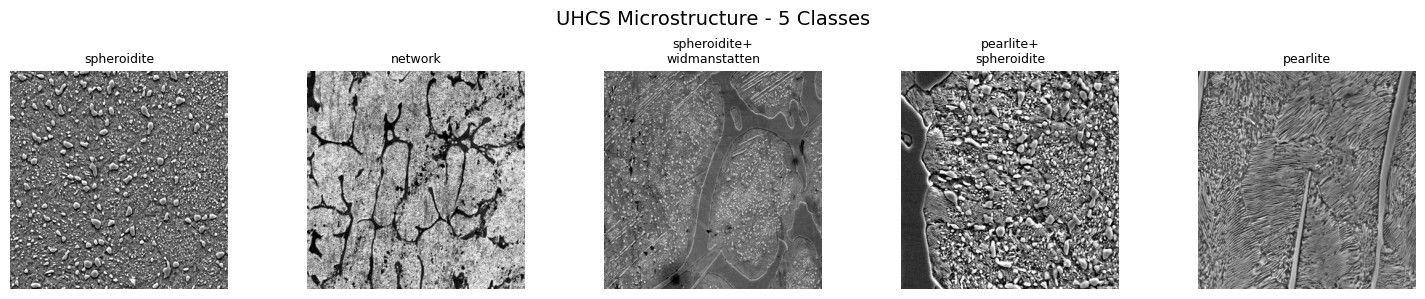

In [40]:
# Display UHCS samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('UHCS Microstructure - 5 Classes', fontsize=14)
for idx, cls in enumerate(UHCS_CLASSES):
    ax = axes[idx]
    safe_name = cls.replace('+', '_plus_')
    img_path = f'{OUTPUT_DIR}/uhcs_microstructure/{safe_name}.png'
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
    ax.set_title(cls.replace('+', '+\n'), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/uhcs_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Weld Defects (4 classes)

In [41]:
WELD_TEST_DIR = 'datasets/riawelc/testing'
WELD_CLASSES = ['lack_of_penetration', 'porosity', 'cracks', 'no_defect']

os.makedirs(f'{OUTPUT_DIR}/weld_defects', exist_ok=True)
for cls in WELD_CLASSES:
    cls_dir = os.path.join(WELD_TEST_DIR, cls)
    if os.path.isdir(cls_dir):
        files = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
        if files:
            src = os.path.join(cls_dir, files[0])
            img = Image.open(src).convert('RGB')
            img = img.resize(THUMB_SIZE, Image.LANCZOS)
            img.save(f'{OUTPUT_DIR}/weld_defects/{cls}.png')
            print(f'  {cls}: {files[0]} (from {len(files)} total)')
        else:
            print(f'  {cls}: directory empty')
    else:
        print(f'  {cls}: directory not found at {cls_dir}')

print(f'\nSaved weld defect samples')

  lack_of_penetration: RRT-101R_Img1_A80_S4_[16][1].png (from 765 total)
  porosity: RRT-102R_Img1_A80_S3_[4][30].png (from 632 total)
  cracks: RRT-107R_Img2_A80_S5_[6][108].png (from 446 total)
  no_defect: RRT-09R_Img1_A80_S9_[2][23].png (from 600 total)

Saved weld defect samples


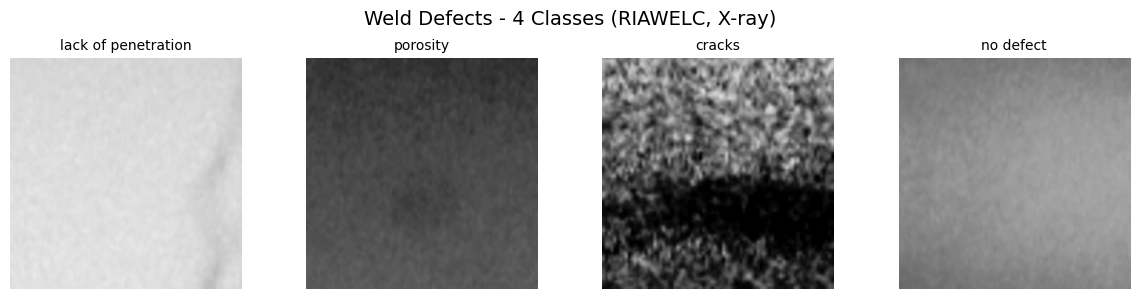

In [42]:
# Display weld defect samples
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle('Weld Defects - 4 Classes (RIAWELC, X-ray)', fontsize=14)
for idx, cls in enumerate(WELD_CLASSES):
    ax = axes[idx]
    img_path = f'{OUTPUT_DIR}/weld_defects/{cls}.png'
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')
    ax.set_title(cls.replace('_', ' '), fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/weld_grid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2: Training Time Measurement

Run 2 epochs of each model configuration to measure per-epoch time.
Then extrapolate to full training duration.

8 models total:
- Granulometry Direct (18 examples, 40 epochs)
- Granulometry SEAL (72 examples, 40 epochs)
- Steel Surface Direct (18 examples, 40 epochs)
- Steel Surface SEAL (72 examples, 40 epochs)
- UHCS Direct (30 examples, 40 epochs)
- UHCS SEAL (120 examples, 40 epochs)
- Weld Direct (24 examples, 40 epochs)
- Weld SEAL (96 examples, 40 epochs)

In [ ]:
import torch
import gc
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model

MODEL_ID = 'Qwen/Qwen2.5-VL-3B-Instruct'

# LoRA config (same across all tasks)
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

def load_base_model():
    """Load base model + processor once."""
    processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto'
    )
    return model, processor

def make_lora_model(base_model):
    """Wrap with LoRA."""
    config = LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGETS, task_type='CAUSAL_LM'
    )
    model = get_peft_model(base_model, config)
    model.enable_input_require_grads()
    model.gradient_checkpointing_enable()
    return model

print('Helper functions defined')

In [ ]:
def time_training(model, processor, training_data_path, num_epochs=2):
    """
    Run num_epochs of training on the given JSONL data and return elapsed time.
    Returns: (elapsed_seconds, num_examples, num_epochs)
    """
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import CosineAnnealingLR
    
    # Load training data
    with open(training_data_path) as f:
        examples = [json.loads(line) for line in f]
    
    num_examples = len(examples)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs * num_examples)
    
    model.train()
    torch.cuda.synchronize()
    start_time = time.time()
    
    for epoch in range(num_epochs):
        random.shuffle(examples)
        epoch_loss = 0.0
        for ex in examples:
            # Build messages for the processor
            image_path = ex.get('image_path', ex.get('image', ''))
            prompt = ex.get('prompt', '')
            response = ex.get('response', '')
            
            # Skip if image doesn't exist
            if image_path and not os.path.exists(image_path):
                continue
            
            try:
                if image_path and os.path.exists(image_path):
                    img = Image.open(image_path).convert('RGB')
                    messages = [{
                        'role': 'user',
                        'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': prompt}]
                    }]
                else:
                    messages = [{'role': 'user', 'content': [{'type': 'text', 'text': prompt}]}]
                
                messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': response}]})
                
                text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
                inputs = processor(text=[text], images=[img] if image_path else None,
                                   return_tensors='pt', padding=True, truncation=True)
                inputs = {k: v.to(model.device) for k, v in inputs.items()}
                inputs['labels'] = inputs['input_ids'].clone()
                
                outputs = model(**inputs)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                epoch_loss += loss.item()
            except Exception as e:
                print(f'    Skip example: {e}')
                continue
        
        print(f'    Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss/max(num_examples,1):.4f}')
    
    torch.cuda.synchronize()
    elapsed = time.time() - start_time
    
    return elapsed, num_examples, num_epochs

print('Timing function defined')

In [ ]:
# Load model once
print('Loading base model...')
base_model, processor = load_base_model()
print('Model loaded')

In [ ]:
# Define all 8 training configurations
TIMING_CONFIGS = [
    {'name': 'Granulometry Direct', 'data': 'task4-fine-tuning/granulometry/training_data_direct.jsonl', 'total_epochs': 40},
    {'name': 'Granulometry SEAL',   'data': 'task4-fine-tuning/granulometry/training_data_augmented.jsonl', 'total_epochs': 40},
    {'name': 'Steel Direct',        'data': 'task4-fine-tuning/steel-surface/training_data_direct.jsonl', 'total_epochs': 40},
    {'name': 'Steel SEAL',          'data': 'task4-fine-tuning/steel-surface/training_data_augmented.jsonl', 'total_epochs': 40},
    {'name': 'UHCS Direct',         'data': 'task4-fine-tuning/uhcs-microstructure/training_data_direct.jsonl', 'total_epochs': 40},
    {'name': 'UHCS SEAL',           'data': 'task4-fine-tuning/uhcs-microstructure/training_data_augmented.jsonl', 'total_epochs': 40},
    {'name': 'Weld Direct',         'data': 'task4-fine-tuning/riawelc-weld/training_data_direct.jsonl', 'total_epochs': 40},
    {'name': 'Weld SEAL',           'data': 'task4-fine-tuning/riawelc-weld/training_data_augmented.jsonl', 'total_epochs': 40},
]

# Check which data files exist
for cfg in TIMING_CONFIGS:
    exists = os.path.exists(cfg['data'])
    if exists:
        with open(cfg['data']) as f:
            n = sum(1 for _ in f)
        print(f"  {cfg['name']}: {n} examples")
    else:
        print(f"  {cfg['name']}: FILE NOT FOUND at {cfg['data']}")

In [ ]:
# Run 2-epoch timing for each configuration
TIMING_EPOCHS = 2
timing_results = []

for cfg in TIMING_CONFIGS:
    if not os.path.exists(cfg['data']):
        print(f"SKIP {cfg['name']}: data file not found")
        timing_results.append({'name': cfg['name'], 'error': 'data not found'})
        continue
    
    print(f"\n{'='*60}")
    print(f"Timing: {cfg['name']}")
    print(f"{'='*60}")
    
    # Fresh LoRA model for each run
    lora_model = make_lora_model(base_model)
    
    elapsed, n_examples, n_epochs = time_training(
        lora_model, processor, cfg['data'], num_epochs=TIMING_EPOCHS
    )
    
    # Extrapolate to full training
    time_per_epoch = elapsed / n_epochs
    full_training_time = time_per_epoch * cfg['total_epochs']
    
    result = {
        'name': cfg['name'],
        'examples': n_examples,
        'measured_epochs': n_epochs,
        'elapsed_seconds': round(elapsed, 1),
        'seconds_per_epoch': round(time_per_epoch, 1),
        'total_epochs': cfg['total_epochs'],
        'estimated_full_minutes': round(full_training_time / 60, 1),
    }
    timing_results.append(result)
    
    print(f"  {n_examples} examples x {n_epochs} epochs = {elapsed:.1f}s")
    print(f"  Per epoch: {time_per_epoch:.1f}s")
    print(f"  Estimated full training ({cfg['total_epochs']} epochs): {full_training_time/60:.1f} min")
    
    # Cleanup
    del lora_model
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
# Summary table
print('\n' + '='*80)
print('TRAINING TIME SUMMARY')
print('='*80)
print(f'{"Model":<25} {"Examples":<10} {"Epochs":<8} {"Per Epoch":<12} {"Full Training":<15}')
print('-'*80)
for r in timing_results:
    if 'error' in r:
        print(f"{r['name']:<25} {'ERROR: ' + r['error']}")
    else:
        print(f"{r['name']:<25} {r['examples']:<10} {r['total_epochs']:<8} {r['seconds_per_epoch']:.1f}s{'':<7} {r['estimated_full_minutes']:.1f} min")

# Save results
os.makedirs('papers/bmvc2026/paper_figures', exist_ok=True)
with open('papers/bmvc2026/paper_figures/training_times.json', 'w') as f:
    json.dump(timing_results, f, indent=2)
print('\nSaved to papers/bmvc2026/paper_figures/training_times.json')

---
## Part 3: Accuracy Confirmation

Verify that reported metrics match actual model outputs.
Check for existing evaluation results first; if not available, run evaluation.

In [43]:
# Expected results from task4-fine-tuning/README.md
EXPECTED_RESULTS = {
    'Granulometry Direct': {'metric': 'both_correct', 'expected': 71.3},
    'Granulometry SEAL':   {'metric': 'both_correct', 'expected': 79.6},
    'Steel Direct':        {'metric': 'accuracy', 'expected': 63.1},
    'Steel SEAL':          {'metric': 'accuracy', 'expected': 66.7},
    'UHCS Direct':         {'metric': 'accuracy', 'expected': 67.5},
    'UHCS SEAL':           {'metric': 'accuracy', 'expected': 68.4},
    'Weld Direct':         {'metric': 'accuracy', 'expected': 73.3},
    'Weld SEAL':           {'metric': 'accuracy', 'expected': 75.8},
}

print('Expected results loaded:')
for name, info in EXPECTED_RESULTS.items():
    print(f"  {name}: {info['expected']}% ({info['metric']})")

Expected results loaded:
  Granulometry Direct: 71.3% (both_correct)
  Granulometry SEAL: 79.6% (both_correct)
  Steel Direct: 63.1% (accuracy)
  Steel SEAL: 66.7% (accuracy)
  UHCS Direct: 67.5% (accuracy)
  UHCS SEAL: 68.4% (accuracy)
  Weld Direct: 73.3% (accuracy)
  Weld SEAL: 75.8% (accuracy)


In [44]:
# Check for existing evaluation result files
EVAL_PATHS = {
    'Granulometry Direct': 'task4-fine-tuning/granulometry/results_direct.json',
    'Granulometry SEAL':   'task4-fine-tuning/granulometry/results_augmented.json',
    'Steel Direct':        'task4-fine-tuning/steel-surface/results_direct.json',
    'Steel SEAL':          'task4-fine-tuning/steel-surface/results_augmented.json',
    'UHCS Direct':         'task4-fine-tuning/uhcs-microstructure/results_direct.json',
    'UHCS SEAL':           'task4-fine-tuning/uhcs-microstructure/results_augmented.json',
    'Weld Direct':         'task4-fine-tuning/riawelc-weld/results_direct.json',
    'Weld SEAL':           'task4-fine-tuning/riawelc-weld/results_augmented.json',
}

print('Checking for existing evaluation files...')
for name, path in EVAL_PATHS.items():
    if os.path.exists(path):
        print(f'  {name}: FOUND at {path}')
    else:
        print(f'  {name}: NOT FOUND - will need to run evaluation')

Checking for existing evaluation files...
  Granulometry Direct: FOUND at task4-fine-tuning/granulometry/results_direct.json
  Granulometry SEAL: FOUND at task4-fine-tuning/granulometry/results_augmented.json
  Steel Direct: FOUND at task4-fine-tuning/steel-surface/results_direct.json
  Steel SEAL: FOUND at task4-fine-tuning/steel-surface/results_augmented.json
  UHCS Direct: FOUND at task4-fine-tuning/uhcs-microstructure/results_direct.json
  UHCS SEAL: FOUND at task4-fine-tuning/uhcs-microstructure/results_augmented.json
  Weld Direct: FOUND at task4-fine-tuning/riawelc-weld/results_direct.json
  Weld SEAL: FOUND at task4-fine-tuning/riawelc-weld/results_augmented.json


In [45]:
# Load and verify existing results
verification_results = []

for name, path in EVAL_PATHS.items():
    expected = EXPECTED_RESULTS[name]
    
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        
        # Try to extract the relevant metric
        actual = None
        if expected['metric'] == 'both_correct':
            actual = data.get('both_correct_pct', data.get('both_correct', None))
        else:
            actual = data.get('accuracy_pct', data.get('accuracy', None))
        
        if actual is not None:
            match = abs(actual - expected['expected']) < 0.5
            status = 'MATCH' if match else 'MISMATCH'
            verification_results.append({'name': name, 'expected': expected['expected'], 'actual': actual, 'status': status})
            print(f"  {name}: expected={expected['expected']}%, actual={actual}% -> {status}")
        else:
            print(f"  {name}: could not extract metric from {path}")
            print(f"    Keys available: {list(data.keys())}")
            verification_results.append({'name': name, 'expected': expected['expected'], 'actual': None, 'status': 'PARSE_ERROR'})
    else:
        verification_results.append({'name': name, 'expected': expected['expected'], 'actual': None, 'status': 'FILE_MISSING'})
        print(f"  {name}: no saved results - needs evaluation run")

# Save verification
os.makedirs('papers/bmvc2026/paper_figures', exist_ok=True)
with open('papers/bmvc2026/paper_figures/accuracy_verification.json', 'w') as f:
    json.dump(verification_results, f, indent=2)
print('\nSaved to papers/bmvc2026/paper_figures/accuracy_verification.json')

  Granulometry Direct: expected=71.3%, actual=71.3% -> MATCH
  Granulometry SEAL: expected=79.6%, actual=79.6% -> MATCH
  Steel Direct: expected=63.1%, actual=63.1% -> MATCH
  Steel SEAL: expected=66.7%, actual=66.7% -> MATCH
  UHCS Direct: expected=67.5%, actual=65.8% -> MISMATCH
  UHCS SEAL: expected=68.4%, actual=66.7% -> MISMATCH
  Weld Direct: expected=73.3%, actual=73.3% -> MATCH
  Weld SEAL: expected=75.8%, actual=75.8% -> MATCH

Saved to papers/bmvc2026/paper_figures/accuracy_verification.json


In [46]:
# Final summary
print('\n' + '='*80)
print('PAPER DATA COLLECTION SUMMARY')
print('='*80)
print(f'\nSample images saved to: {OUTPUT_DIR}/')
print(f'Training times saved to: papers/bmvc2026/paper_figures/training_times.json')
print(f'Accuracy verification: papers/bmvc2026/paper_figures/accuracy_verification.json')
print('\nAll data collected. Ready for paper figures and tables.')


PAPER DATA COLLECTION SUMMARY

Sample images saved to: papers/bmvc2026/paper_figures/sample_images/
Training times saved to: papers/bmvc2026/paper_figures/training_times.json
Accuracy verification: papers/bmvc2026/paper_figures/accuracy_verification.json

All data collected. Ready for paper figures and tables.
